**Team Zero 4 :-
ID : 0432220005101026,
     0432220005101033,
     0432220005101049,
     0432220005101050** 🥰

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Data mining models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Deep learning model
import tensorflow as tf

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
file_path = "/content/drive/MyDrive/CSE-Data-Mining-Warehouse-Lab-426/Data Mining Project /heart.csv"
data = pd.read_csv(file_path)

# Show first rows
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Check dataset shape
print("Dataset shape:", data.shape)

# Check missing values
print(data.isnull().sum())

# Statistical summary
data.describe()

Dataset shape: (1025, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Split features and target
X = data.drop("target", axis=1)
y = data["target"]

In [6]:
# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for NN and ML)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

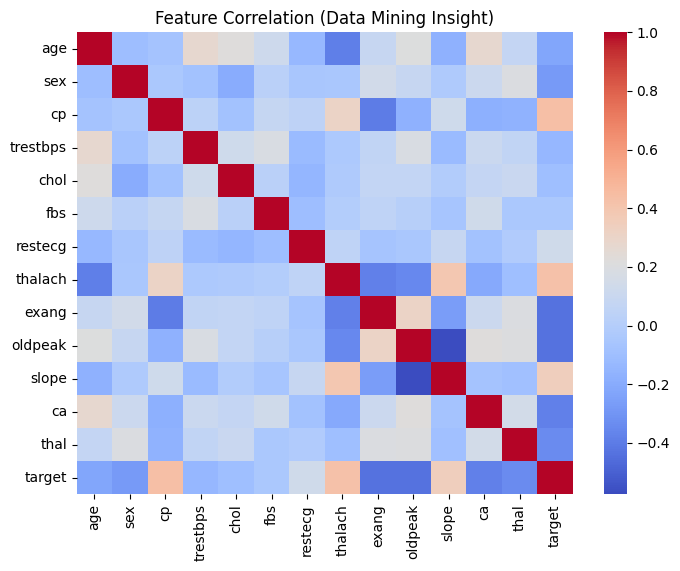

In [7]:
# Correlation analysis (Data Mining step)
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation (Data Mining Insight)")
plt.show()

In [8]:
# Build Artificial Neural Network
nn_model = tf.keras.models.Sequential()

nn_model.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(x_train.shape[1],)))
nn_model.add(tf.keras.layers.Dense(8, activation='relu'))
nn_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Compile model
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = nn_model.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_test, y_test),
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Logistic Regression (Data Mining classifier)
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)


# Decision Tree (Data Mining classifier)
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Logistic Regression Accuracy: 0.7951219512195122
Decision Tree Accuracy: 0.9853658536585366


In [10]:
# Neural Network accuracy
loss, nn_acc = nn_model.evaluate(x_test, y_test, verbose=0)
print("Neural Network Accuracy:", nn_acc)

Neural Network Accuracy: 0.8682926893234253


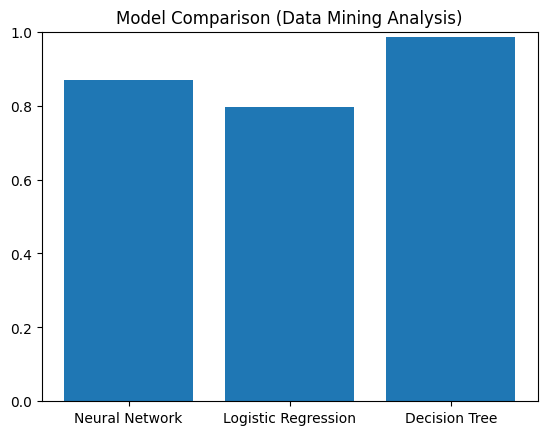

In [11]:
# Model comparison
models = ["Neural Network", "Logistic Regression", "Decision Tree"]
accuracy = [nn_acc, lr_acc, dt_acc]

plt.bar(models, accuracy)
plt.title("Model Comparison (Data Mining Analysis)")
plt.ylim(0,1)
plt.show()

In [12]:
# Prediction demo
sample = x_test[0].reshape(1, -1)

prediction = nn_model.predict(sample)

if prediction[0][0] > 0.5:
    print("Prediction: Heart Disease Detected ❤️")
else:
    print("Prediction: No Heart Disease 💚")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Prediction: Heart Disease Detected ❤️


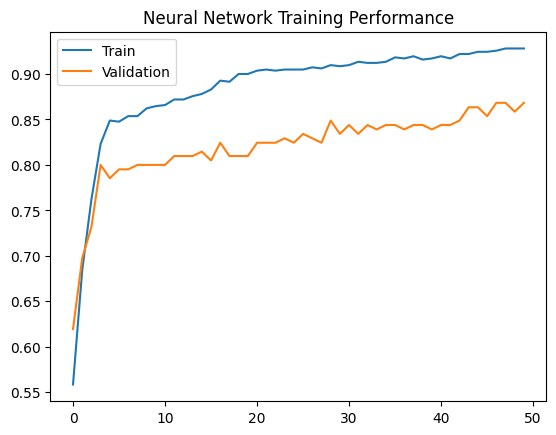

In [13]:
# Training performance graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Neural Network Training Performance")
plt.legend(['Train', 'Validation'])
plt.show()